In [23]:
import ast
import cv2
import numpy as np
import pandas as pd
import IPython
import face_recognition
from retinaface import RetinaFace

In [2]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [3]:
def draw_faces(image, faces):
    for face, data in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = data['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

2025-01-19 11:44:16.346824: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-01-19 11:44:16.346850: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:134] retrieving CUDA diagnostic information for host: pc
2025-01-19 11:44:16.346857: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:141] hostname: pc
2025-01-19 11:44:16.346939: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:165] libcuda reported version is: 535.183.1
2025-01-19 11:44:16.346958: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:169] kernel reported version is: 535.183.1
2025-01-19 11:44:16.346964: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:248] kernel version seems to match DSO: 535.183.1


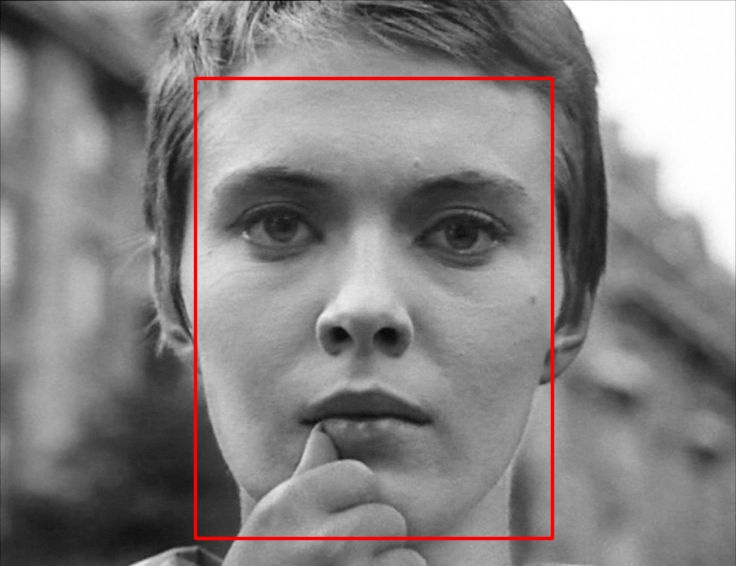

In [4]:
src = './images/img_1.jpg'
img = cv2.imread(src)
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)

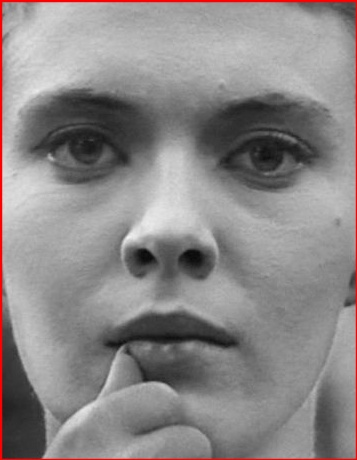

195 78 552 538


In [5]:
x1, y1, x2, y2 = faces['face_1']['facial_area']
face = img[y1:y2, x1:x2]
show_image(face)
print(x1, y1, x2, y2)

In [6]:
rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
h, w = rgb.shape[:2]
encoding = face_recognition.face_encodings(rgb, known_face_locations=[[0, w, h, 0]])[0]
encoding

array([-1.47894785e-01,  5.60405999e-02,  9.09666196e-02, -1.50613710e-01,
       -6.89018816e-02, -9.22461972e-02, -5.84694929e-03, -1.60795644e-01,
        1.23146951e-01, -1.29785895e-01,  1.72482312e-01, -7.95929357e-02,
       -3.32599521e-01,  2.08141115e-02, -6.86838925e-02,  1.20681956e-01,
       -2.54942596e-01, -1.77085981e-01, -2.14887932e-02, -4.12624367e-02,
        1.65453255e-01,  1.10440880e-01, -4.09107246e-02,  5.34842275e-02,
       -6.40489087e-02, -2.73009479e-01, -7.86216855e-02, -5.97209707e-02,
       -2.25622691e-02,  4.93889078e-02, -2.32017599e-03,  7.04465955e-02,
       -2.09908873e-01, -1.97241642e-02,  3.56527753e-02,  1.05786704e-01,
       -4.58054058e-02, -1.21372454e-01,  1.57426059e-01,  6.10969216e-03,
       -1.83302894e-01, -2.27034502e-02,  5.68773001e-02,  1.78184986e-01,
        1.68550402e-01, -7.05728121e-03, -2.94753108e-02, -1.72194391e-01,
        1.35783106e-01, -3.16808969e-01, -8.21685232e-03,  2.34215274e-01,
        6.53007254e-02,  

In [19]:
# np.set_printoptions(suppress=True)
df = pd.DataFrame([{'array': np.array2string(encoding, separator=',').replace('\n', '').replace(' ', '')}])
df.head()

,array
0,"[-1.47894785e-01,5.60405999e-02,9.09666196e-02..."


In [20]:
df.to_csv('../data/test.csv')

In [21]:
reloaded_df = pd.read_csv('../data/test.csv', index_col=0)
reloaded_df.head()

,array
0,"[-1.47894785e-01,5.60405999e-02,9.09666196e-02..."


In [22]:
reloaded_encoding = reloaded_df.at[0, 'array']
reloaded_encoding

'[-1.47894785e-01,5.60405999e-02,9.09666196e-02,-1.50613710e-01,-6.89018816e-02,-9.22461972e-02,-5.84694929e-03,-1.60795644e-01,1.23146951e-01,-1.29785895e-01,1.72482312e-01,-7.95929357e-02,-3.32599521e-01,2.08141115e-02,-6.86838925e-02,1.20681956e-01,-2.54942596e-01,-1.77085981e-01,-2.14887932e-02,-4.12624367e-02,1.65453255e-01,1.10440880e-01,-4.09107246e-02,5.34842275e-02,-6.40489087e-02,-2.73009479e-01,-7.86216855e-02,-5.97209707e-02,-2.25622691e-02,4.93889078e-02,-2.32017599e-03,7.04465955e-02,-2.09908873e-01,-1.97241642e-02,3.56527753e-02,1.05786704e-01,-4.58054058e-02,-1.21372454e-01,1.57426059e-01,6.10969216e-03,-1.83302894e-01,-2.27034502e-02,5.68773001e-02,1.78184986e-01,1.68550402e-01,-7.05728121e-03,-2.94753108e-02,-1.72194391e-01,1.35783106e-01,-3.16808969e-01,-8.21685232e-03,2.34215274e-01,6.53007254e-02,8.63830149e-02,5.53476512e-02,-2.54907340e-01,5.81301190e-02,1.39761910e-01,-2.65359402e-01,6.07324205e-02,3.64247262e-02,-1.70387223e-01,5.50430492e-02,-1.03580117e-01,1.

In [25]:
l = ast.literal_eval(reloaded_encoding)
type(l)

list

In [26]:
a = np.array(l)
type(a)

numpy.ndarray

In [27]:
a

array([-1.47894785e-01,  5.60405999e-02,  9.09666196e-02, -1.50613710e-01,
       -6.89018816e-02, -9.22461972e-02, -5.84694929e-03, -1.60795644e-01,
        1.23146951e-01, -1.29785895e-01,  1.72482312e-01, -7.95929357e-02,
       -3.32599521e-01,  2.08141115e-02, -6.86838925e-02,  1.20681956e-01,
       -2.54942596e-01, -1.77085981e-01, -2.14887932e-02, -4.12624367e-02,
        1.65453255e-01,  1.10440880e-01, -4.09107246e-02,  5.34842275e-02,
       -6.40489087e-02, -2.73009479e-01, -7.86216855e-02, -5.97209707e-02,
       -2.25622691e-02,  4.93889078e-02, -2.32017599e-03,  7.04465955e-02,
       -2.09908873e-01, -1.97241642e-02,  3.56527753e-02,  1.05786704e-01,
       -4.58054058e-02, -1.21372454e-01,  1.57426059e-01,  6.10969216e-03,
       -1.83302894e-01, -2.27034502e-02,  5.68773001e-02,  1.78184986e-01,
        1.68550402e-01, -7.05728121e-03, -2.94753108e-02, -1.72194391e-01,
        1.35783106e-01, -3.16808969e-01, -8.21685232e-03,  2.34215274e-01,
        6.53007254e-02,  